### Group Prject - London Bike Rentals

In this project, you will work with the London Bikes dataset, which records daily bike rentals in the city along with key variables such as dates, weather conditions, and seasonality.

The goal is to apply the full data analytics workflow:

- Clean and prepare the dataset.

- Explore the data through visualisation.

- Construct and interpret confidence intervals.

- Build a regression model to explain variation in bike rentals.

- By the end, you will connect statistical concepts with practical Python analysis.

In [13]:
## Import libraries and data
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.formula.api as smf
from scipy import stats


pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
bikes = pd.read_csv('../Data/london_bikes.csv')
bikes.head(10)

,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,precipitation,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend
0,2010-07-30T00:00:00Z,6897,2010,Fri,Jul,30,6.000,65.000,"10,147.000",157.000,22.000,NaN,31.000,17.700,12.300,25.100,False
1,2010-07-31T00:00:00Z,5564,2010,Sat,Jul,30,5.000,70.000,"10,116.000",184.000,0.000,NaN,47.000,21.100,17.000,23.900,True
2,2010-08-01T00:00:00Z,4303,2010,Sun,Aug,30,7.000,63.000,"10,132.000",89.000,0.000,NaN,3.000,19.300,14.600,23.400,True
3,2010-08-02T00:00:00Z,6642,2010,Mon,Aug,31,7.000,59.000,"10,168.000",134.000,0.000,NaN,20.000,19.500,15.600,23.600,False
4,2010-08-03T00:00:00Z,7966,2010,Tue,Aug,31,5.000,66.000,"10,157.000",169.000,0.000,NaN,39.000,17.900,12.100,20.100,False
5,2010-08-04T00:00:00Z,7893,2010,Wed,Aug,31,6.000,75.000,"10,080.000",121.000,32.000,NaN,15.000,17.400,14.700,22.600,False
6,2010-08-05T00:00:00Z,8724,2010,Thu,Aug,31,4.000,58.000,"10,125.000",227.000,0.000,NaN,79.000,17.300,11.900,21.400,False
7,2010-08-06T00:00:00Z,9797,2010,Fri,Aug,31,6.000,75.000,"10,148.000",141.000,26.000,NaN,25.000,16.400,11.300,21.800,False
8,2010-08-07T00:00:00Z,6631,2010,Sat,Aug,31,7.000,78.000,"10,148.000",112.000,10.000,NaN,12.000,18.900,15.900,24.500,True
9,2010-08-08T00:00:00Z,7864,2010,Sun,Aug,31,4.000,64.000,"10,194.000",201.000,0.000,NaN,62.000,19.000,13.500,25.100,True


**1. Data Cleaning**

Check for missing values across columns. How would you handle them?

Inspect the date column and ensure it is correctly formatted as datetime. Extract useful features (year, month, day, day of week, season).

Convert categorical variables (e.g., season, weather) to appropriate categories in Python.

Ensure numeric columns (e.g., bikes rented, temperature) are in the right format.

Check for missing values across columns. How would you handle them?

In [ ]:
print("Base Dataset Null values count:", bikes.isnull().sum().sum())
print("Missing Values for each column in the df\n", bikes.isnull().sum(), sep="")

# checking for missing values 
missing_rows = bikes[bikes.isnull().any(axis=1)]
display(missing_rows.head(10))
display((bikes.isnull().mean() * 100).round(1))
display(bikes[bikes["month"] == "Jul"])

Base Dataset Null values count: 675
Missing Values for each column in the df
date               0
bikes_hired        0
year               0
wday               0
month              0
week               0
cloud_cover       33
humidity          83
pressure          31
radiation         40
precipitation     31
snow_depth       302
sunshine          31
mean_temp         31
min_temp          62
max_temp          31
weekend            0
dtype: int64


,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,precipitation,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend
0,2010-07-30T00:00:00Z,6897,2010,Fri,Jul,30,6.000,65.000,"10,147.000",157.000,22.000,NaN,31.000,17.700,12.300,25.100,False
1,2010-07-31T00:00:00Z,5564,2010,Sat,Jul,30,5.000,70.000,"10,116.000",184.000,0.000,NaN,47.000,21.100,17.000,23.900,True
2,2010-08-01T00:00:00Z,4303,2010,Sun,Aug,30,7.000,63.000,"10,132.000",89.000,0.000,NaN,3.000,19.300,14.600,23.400,True
3,2010-08-02T00:00:00Z,6642,2010,Mon,Aug,31,7.000,59.000,"10,168.000",134.000,0.000,NaN,20.000,19.500,15.600,23.600,False
4,2010-08-03T00:00:00Z,7966,2010,Tue,Aug,31,5.000,66.000,"10,157.000",169.000,0.000,NaN,39.000,17.900,12.100,20.100,False
5,2010-08-04T00:00:00Z,7893,2010,Wed,Aug,31,6.000,75.000,"10,080.000",121.000,32.000,NaN,15.000,17.400,14.700,22.600,False
6,2010-08-05T00:00:00Z,8724,2010,Thu,Aug,31,4.000,58.000,"10,125.000",227.000,0.000,NaN,79.000,17.300,11.900,21.400,False
7,2010-08-06T00:00:00Z,9797,2010,Fri,Aug,31,6.000,75.000,"10,148.000",141.000,26.000,NaN,25.000,16.400,11.300,21.800,False
8,2010-08-07T00:00:00Z,6631,2010,Sat,Aug,31,7.000,78.000,"10,148.000",112.000,10.000,NaN,12.000,18.900,15.900,24.500,True
9,2010-08-08T00:00:00Z,7864,2010,Sun,Aug,31,4.000,64.000,"10,194.000",201.000,0.000,NaN,62.000,19.000,13.500,25.100,True


date            0.000
bikes_hired     0.000
year            0.000
wday            0.000
month           0.000
week            0.000
cloud_cover     0.700
humidity        1.700
pressure        0.600
radiation       0.800
precipitation   0.600
snow_depth      6.100
sunshine        0.600
mean_temp       0.600
min_temp        1.300
max_temp        0.600
weekend         0.000
dtype: float64

,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,precipitation,sunshine,mean_temp,min_temp,max_temp,weekend
0,2010-07-30T00:00:00Z,6897,2010,Fri,Jul,30,6.000,65.000,"10,147.000",157.000,22.000,31.000,17.700,12.300,25.100,False
1,2010-07-31T00:00:00Z,5564,2010,Sat,Jul,30,5.000,70.000,"10,116.000",184.000,0.000,47.000,21.100,17.000,23.900,True
336,2011-07-01T00:00:00Z,27758,2011,Fri,Jul,26,3.000,54.000,"10,258.000",274.000,0.000,97.000,15.300,9.900,22.800,False
337,2011-07-02T00:00:00Z,22764,2011,Sat,Jul,26,4.000,55.000,"10,199.000",232.000,0.000,68.000,18.100,13.400,24.100,True
338,2011-07-03T00:00:00Z,21423,2011,Sun,Jul,26,4.000,55.000,"10,176.000",244.000,0.000,76.000,17.700,11.300,25.500,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4745,2023-07-27T00:00:00Z,28322,2023,Thu,Jul,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4746,2023-07-28T00:00:00Z,26933,2023,Fri,Jul,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4747,2023-07-29T00:00:00Z,25104,2023,Sat,Jul,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4748,2023-07-30T00:00:00Z,14707,2023,Sun,Jul,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


Inspect the date column and ensure it is correctly formatted as datetime. Extract useful features (year, month, day, day of week, season).

In [6]:
# Inspect the date column and ensure it is correctly formatted as datetime. 
# Extract useful features (year, month, day, day of week, season).
# set the date to date time 
bikes["date"] = pd.to_datetime(bikes["date"])

# Create useful date variables
bikes["year"] = bikes["date"].dt.year
bikes["month"] = bikes["date"].dt.month
bikes["month_name"] = bikes["date"].dt.month_name()
bikes["day"] = bikes["date"].dt.day
bikes["day_of_week"] = bikes["date"].dt.day_name()

# Create season
bikes["season"] = np.select(
    [
        bikes["month"].isin([12, 1, 2]),
        bikes["month"].isin([3, 4, 5]),
        bikes["month"].isin([6, 7, 8]),
        bikes["month"].isin([9, 10, 11])
    ],
    ["Winter", "Spring", "Summer", "Autumn"],
    default="Unknown"
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
bikes["season"] = pd.Categorical(
    bikes["season"],
    categories=season_order,
    ordered=True
)

bikes.head(10)

,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,...,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend,month_name,day,day_of_week,season
0,2010-07-30 00:00:00+00:00,6897,2010,Fri,7,30,6.000,65.000,"10,147.000",157.000,...,NaN,31.000,17.700,12.300,25.100,False,July,30,Friday,Summer
1,2010-07-31 00:00:00+00:00,5564,2010,Sat,7,30,5.000,70.000,"10,116.000",184.000,...,NaN,47.000,21.100,17.000,23.900,True,July,31,Saturday,Summer
2,2010-08-01 00:00:00+00:00,4303,2010,Sun,8,30,7.000,63.000,"10,132.000",89.000,...,NaN,3.000,19.300,14.600,23.400,True,August,1,Sunday,Summer
3,2010-08-02 00:00:00+00:00,6642,2010,Mon,8,31,7.000,59.000,"10,168.000",134.000,...,NaN,20.000,19.500,15.600,23.600,False,August,2,Monday,Summer
4,2010-08-03 00:00:00+00:00,7966,2010,Tue,8,31,5.000,66.000,"10,157.000",169.000,...,NaN,39.000,17.900,12.100,20.100,False,August,3,Tuesday,Summer
5,2010-08-04 00:00:00+00:00,7893,2010,Wed,8,31,6.000,75.000,"10,080.000",121.000,...,NaN,15.000,17.400,14.700,22.600,False,August,4,Wednesday,Summer
6,2010-08-05 00:00:00+00:00,8724,2010,Thu,8,31,4.000,58.000,"10,125.000",227.000,...,NaN,79.000,17.300,11.900,21.400,False,August,5,Thursday,Summer
7,2010-08-06 00:00:00+00:00,9797,2010,Fri,8,31,6.000,75.000,"10,148.000",141.000,...,NaN,25.000,16.400,11.300,21.800,False,August,6,Friday,Summer
8,2010-08-07 00:00:00+00:00,6631,2010,Sat,8,31,7.000,78.000,"10,148.000",112.000,...,NaN,12.000,18.900,15.900,24.500,True,August,7,Saturday,Summer
9,2010-08-08 00:00:00+00:00,7864,2010,Sun,8,31,4.000,64.000,"10,194.000",201.000,...,NaN,62.000,19.000,13.500,25.100,True,August,8,Sunday,Summer


In [ ]:
# looking deeper into snow depth why are there so many missing values?
print(bikes.groupby('season')['snow_depth'].apply(lambda s: s.isnull().mean()*100).round(1))
print(bikes.groupby('year')['snow_depth'].apply(lambda s: s.isnull().mean()*100).round(1))

# bleh 
print(bikes.groupby('season').apply(lambda s: s.isnull().mean()*100).round(1))
print(bikes.groupby('year').apply(lambda s: s.isnull().mean()*100).round(1))


# 2010 has a lot of missing values lets view the entries for that
display(bikes[(bikes['year'] == 2010) & (bikes['season'] == 'Winter')])

season
Winter    0.200
Spring    4.100
Summer   12.700
Autumn    7.400
Name: snow_depth, dtype: float64
year
2010   57.400
2011   49.300
2012    0.000
2013    0.000
2014    0.000
2015    0.500
2016    0.000
2017    0.000
2018    0.000
2019    0.000
2020    0.000
2021    0.000
2022    0.000
2023    8.500
2024    0.000
Name: snow_depth, dtype: float64


,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,...,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend,month_name,day,day_of_week,season
124,2010-12-01 00:00:00+00:00,9848,2010,Wed,12,48,8.000,65.000,"10,076.000",14.000,...,0.000,0.000,-0.500,-1.300,0.100,False,December,1,Wednesday,Winter
125,2010-12-02 00:00:00+00:00,7356,2010,Thu,12,48,8.000,78.000,"10,078.000",13.000,...,2.000,0.000,-0.600,-1.200,3.600,False,December,2,Thursday,Winter
126,2010-12-03 00:00:00+00:00,8264,2010,Fri,12,48,5.000,85.000,"10,119.000",13.000,...,1.000,0.000,-0.700,-5.000,6.500,False,December,3,Friday,Winter
127,2010-12-04 00:00:00+00:00,7857,2010,Sat,12,48,7.000,91.000,"10,045.000",13.000,...,0.000,0.000,1.200,-4.100,5.000,True,December,4,Saturday,Winter
128,2010-12-05 00:00:00+00:00,8321,2010,Sun,12,48,1.000,90.000,"10,045.000",39.000,...,0.000,38.000,3.000,1.000,-0.400,True,December,5,Sunday,Winter
129,2010-12-06 00:00:00+00:00,13855,2010,Mon,12,49,8.000,94.000,"10,031.000",13.000,...,0.000,0.000,-1.800,-3.100,1.700,False,December,6,Monday,Winter
130,2010-12-07 00:00:00+00:00,15033,2010,Tue,12,49,7.000,86.000,"10,054.000",16.000,...,0.000,2.000,-0.700,-3.000,3.400,False,December,7,Tuesday,Winter
131,2010-12-08 00:00:00+00:00,15225,2010,Wed,12,49,5.000,84.000,"10,132.000",29.000,...,0.000,21.000,1.100,-1.200,4.300,False,December,8,Wednesday,Winter
132,2010-12-09 00:00:00+00:00,16171,2010,Thu,12,49,2.000,75.000,"10,298.000",35.000,...,0.000,32.000,1.100,-2.200,7.100,False,December,9,Thursday,Winter
133,2010-12-10 00:00:00+00:00,15602,2010,Fri,12,49,6.000,87.000,"10,316.000",12.000,...,0.000,0.000,3.200,-0.700,8.700,False,December,10,Friday,Winter


Exploratoratory data analysis 

In [11]:
weather_cols = ['cloud_cover','humidity','pressure','radiation',
                'precipitation','snow_depth','sunshine',
                'mean_temp','min_temp','max_temp']

bikes['n_missing_weather'] = bikes[weather_cols].isnull().sum(axis=1)
bikes['n_missing_weather'].value_counts().sort_index()

n_missing_weather
0     4570
1      301
2       32
10      31
Name: count, dtype: int64

Text(0.5, 1.0, 'Missing weather columns per day over time')

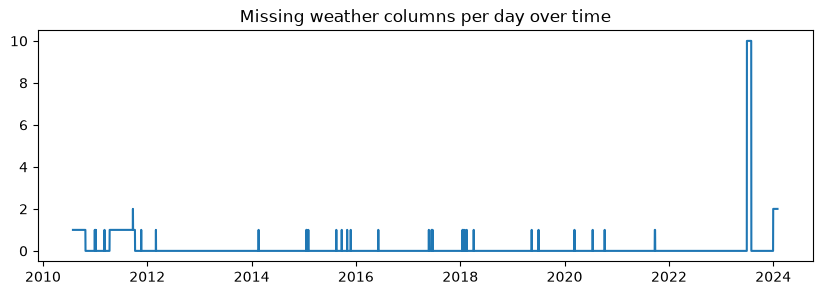

In [12]:
# lets check for missing rows over a period of time
plt.figure(figsize=(10,3))
plt.plot(bikes['date'], bikes['n_missing_weather'])
plt.title('Missing weather columns per day over time')

In [20]:
# We need to drop some stuff and not just leave it in there 

# lets remove the snow depth column since we are not using it and there are a 
# lot missing values
bikes_cleaned = bikes.drop('snow_depth', axis = 1)


Convert categorical variables (e.g., season, weather) to appropriate categories in Python.

Ensure numeric columns (e.g., bikes rented, temperature) are in the right format.

In [ ]:
# yep this works 
print(bikes.dtypes)

date                 datetime64[us, UTC]
bikes_hired                        int64
year                               int32
wday                                 str
month                              int32
week                               int64
cloud_cover                      float64
humidity                         float64
pressure                         float64
radiation                        float64
precipitation                    float64
snow_depth                       float64
sunshine                         float64
mean_temp                        float64
min_temp                         float64
max_temp                         float64
weekend                             bool
month_name                           str
day                                int32
day_of_week                          str
season                          category
n_missing_weather                  int64
dtype: object


**2. Exploratory Data Analysis (EDA)**

Plot the distribution of bikes rented.

Explore how rentals vary by season and month.

Investigate the relationship between temperature and bikes rented.

**Deliverables:**

At least 3 clear visualisations with captions.

A short written interpretation of key patterns (seasonality, weather effects, etc.).



Plot the distribution of bikes rented.

Text(0, 0.5, '')

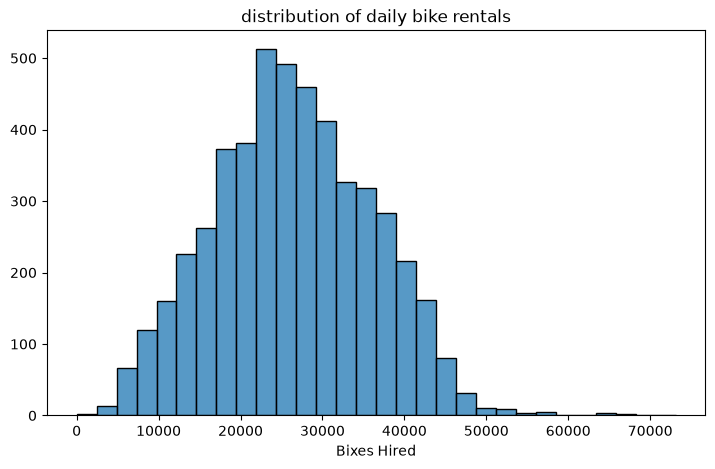

In [6]:
## Your code goes here
plt.figure(figsize=(8.5,5))

sns.histplot(
    data=bikes,
    x="bikes_hired",
    bins=30
)

plt.title("distribution of daily bike rentals")
plt.xlabel("Bixes Hired")
plt.ylabel("")


The number of bikes hired daily appears to be normally distributed with a slight skew to the left.

Explore how rentals vary by season and month.

Text(0, 0.5, 'Bikes Hired')

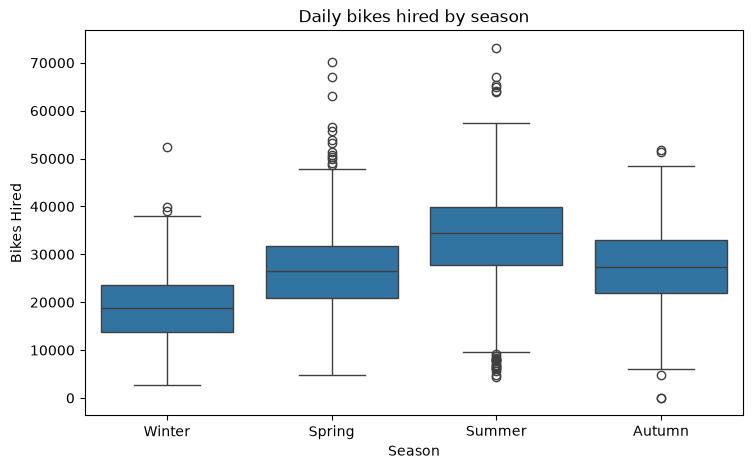

In [7]:
plt.figure(figsize=(8.5,5))

sns.boxplot(
    data=bikes,
    x="season",
    y="bikes_hired"
)

plt.title("Daily bikes hired by season")
plt.xlabel("Season")
plt.ylabel("Bikes Hired")


Text(0, 0.5, 'Bikes Hired')

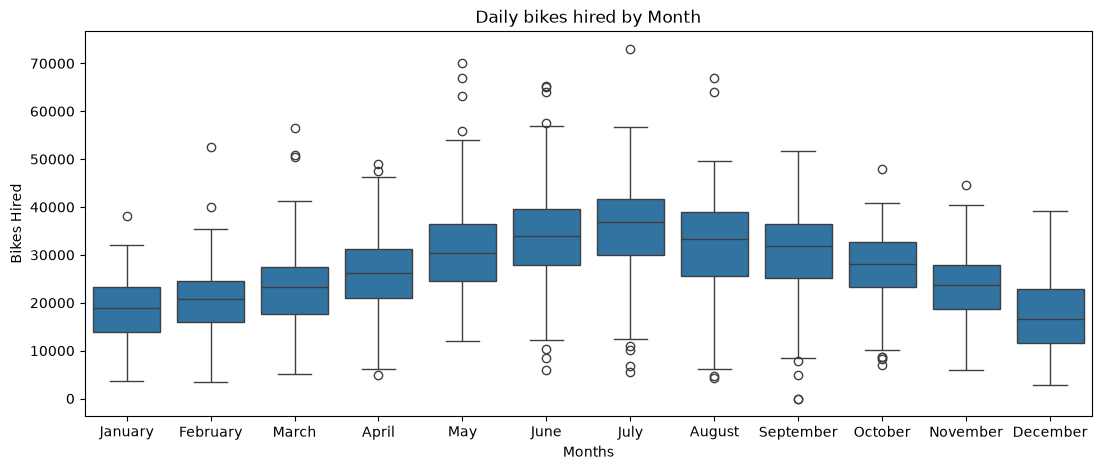

In [37]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

plt.figure(figsize=(13,5))

sns.boxplot(
    data=bikes,
    x="month_name",
    y="bikes_hired",
    order=month_order
)

plt.title("Daily bikes hired by Month")
plt.xlabel("Months")
plt.ylabel("Bikes Hired")

Investigate the relationship between temperature and bikes rented.

Text(0, 0.5, 'Bikes Hired')

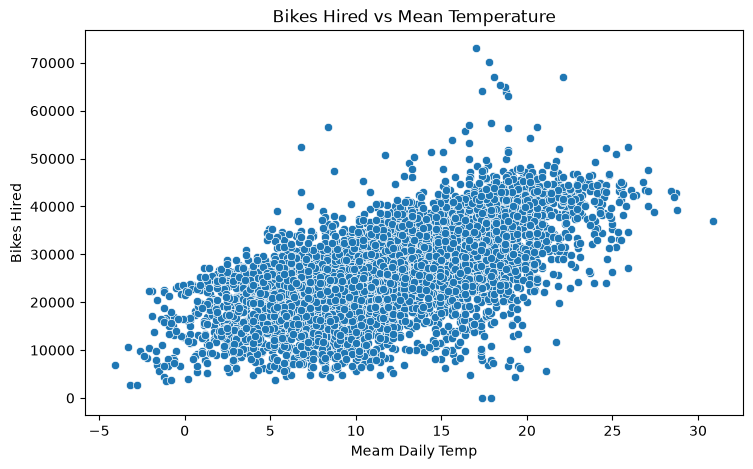

In [9]:
plt.figure(figsize=(8.5,5))

sns.scatterplot(
    data=bikes,
    x="mean_temp",
    y="bikes_hired"
)

plt.title("Bikes Hired vs Mean Temperature")
plt.xlabel("Meam Daily Temp")
plt.ylabel("Bikes Hired")

**Explanation:** The bikes rented seem to peak during the summer season as seen from the seasons graph (graph 1). The second graph reveals that the most popular month to rent bikes is July which is corroberated by the seasonal graph. Lastly there is a positive correlation with bikes rented and temperature. This is justified as the summer months have the highest bikes rentals and the highest temperatures throughout the year.

We postulte that there are more outliers in the summer and spring seasons due to a higher variablility of temperatures in these months. As compared to the winter season which has a lesser variablity in temperature overall. 

**3. Construct 95% confidence intervals for the mean number of bikes rented per season.**

Repeat the calculation per month.

Interpret the result:

What range of values do you expect the true mean to lie in?

Which seasons/months have higher or lower average demand?

Are there overlaps in the intervals, and what does that mean?

**Deliverables:**

A table or plot showing the mean and confidence intervals.

A short interpretation.

In [ ]:
# Confidence Interval (CI) using the formula mean +- t_critical * SE, grouped by season
season_ci = (
    bikes
    .groupby('season', observed=True)
    .agg(
        mean_rentals=('bikes_hired', 'mean'),
        median_rentals=('bikes_hired', 'median'),
        sd_rentals=('bikes_hired', 'std'),
        count=('bikes_hired', 'size')
    )
    .reset_index()
)

# Calculate additional statistics for confidence intervals
season_ci['t_critical'] = season_ci['count'].apply(lambda n: stats.t.ppf(0.95, df=n-1))  # t-critical value
season_ci['se_rentals'] = season_ci['sd_rentals'] / np.sqrt(season_ci['count'])  # Standard error
season_ci['margin_of_error'] = season_ci['t_critical'] * season_ci['se_rentals']  # Margin of error
season_ci['rentals_low'] = season_ci['mean_rentals'] - season_ci['margin_of_error']  # Lower bound
season_ci['rentals_high'] = season_ci['mean_rentals'] + season_ci['margin_of_error']  # Upper bound

season_ci

,season,mean_rentals,median_rentals,sd_rentals,count,t_critical,se_rentals,margin_of_error,rentals_low,rentals_high
0,Winter,"18,610.163","18,802.000","6,625.763",1235,1.646,188.540,310.353,"18,299.810","18,920.516"
1,Spring,"26,609.179","26,469.000","8,660.272",1196,1.646,250.418,412.221,"26,196.958","27,021.400"
2,Summer,"33,455.455","34,524.000","9,147.749",1229,1.646,260.939,429.530,"33,025.925","33,884.985"
3,Autumn,"27,136.845","27,381.000","7,857.506",1274,1.646,220.141,362.363,"26,774.483","27,499.208"


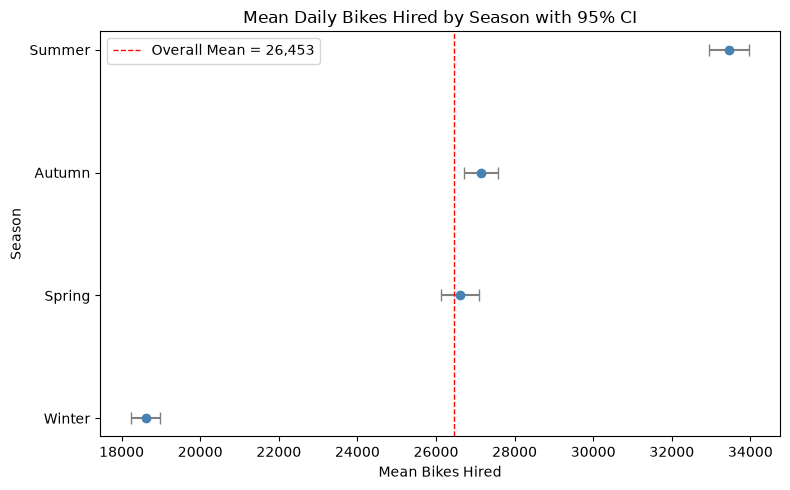

In [11]:
# Sort for plotting (seasons already have a natural order, but sort by mean for readability)
plot_df = season_ci.sort_values('mean_rentals', ascending=True)

plt.figure(figsize=(8, 5))

# Plot the mean rentals as points with horizontal error bars
plt.errorbar(
    x=plot_df['mean_rentals'],            # mean bikes hired
    y=plot_df['season'],                  # season labels
    xerr=plot_df['margin_of_error'],      # half-length of CI
    fmt='o',                              # point marker
    color='steelblue',                    # point color
    ecolor='gray',                        # error bar color
    capsize=4,                            # cap size on error bars
    markersize=6                          # marker size
)

# Add a vertical line for overall mean rentals
overall_mean = plot_df['mean_rentals'].mean()
plt.axvline(
    overall_mean,
    color='red', linestyle='--', linewidth=1,
    label=f'Overall Mean = {overall_mean:,.0f}'
)

# Labels and title
plt.xlabel('Mean Bikes Hired')
plt.ylabel('Season')
plt.title('Mean Daily Bikes Hired by Season with 95% CI')
plt.legend()
plt.tight_layout()
plt.show()

Repeat the calculation per month.

In [ ]:
# Confidence Interval (CI) using the formula mean +- t_critical * SE, grouped by month
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

month_ci = (
    bikes
    .groupby('month_name', observed=True)
    .agg(
        mean_rentals=('bikes_hired', 'mean'),
        median_rentals=('bikes_hired', 'median'),
        sd_rentals=('bikes_hired', 'std'),
        count=('bikes_hired', 'size')
    )
    .reset_index()
)

# Calculate additional statistics for confidence intervals
month_ci['t_critical'] = month_ci['count'].apply(lambda n: stats.t.ppf(0.95, df=n-1))  # t-critical value
month_ci['se_rentals'] = month_ci['sd_rentals'] / np.sqrt(month_ci['count'])  # Standard error
month_ci['margin_of_error'] = month_ci['t_critical'] * month_ci['se_rentals']  # Margin of error
month_ci['rentals_low'] = month_ci['mean_rentals'] - month_ci['margin_of_error']  # Lower bound
month_ci['rentals_high'] = month_ci['mean_rentals'] + month_ci['margin_of_error']  # Upper bound

# Keep calendar order
month_ci['month_name'] = pd.Categorical(month_ci['month_name'], categories=month_order, ordered=True)
month_ci = month_ci.sort_values('month_name').reset_index(drop=True)

month_ci

,month_name,mean_rentals,median_rentals,sd_rentals,count,t_critical,se_rentals,margin_of_error,rentals_low,rentals_high
0,January,"18,652.470","18,964.000","5,992.563",434,1.965,287.652,565.368,"18,087.102","19,217.838"
1,February,"20,370.174","20,713.000","6,528.790",367,1.966,340.800,670.172,"19,700.002","21,040.346"
2,March,"22,851.457","23,390.000","7,739.305",403,1.966,385.522,757.892,"22,093.565","23,609.348"
3,April,"26,242.038","26,211.000","7,775.299",390,1.966,393.718,774.081,"25,467.958","27,016.119"
4,May,"30,722.199","30,426.000","8,561.905",403,1.966,426.499,838.447,"29,883.752","31,560.645"
5,June,"33,744.103","33,851.000","8,765.336",390,1.966,443.850,872.645,"32,871.457","34,616.748"
6,July,"35,160.679","36,932.000","8,371.380",405,1.966,415.977,817.750,"34,342.929","35,978.429"
7,August,"31,604.790","33,293.000","9,832.833",434,1.965,471.991,927.679,"30,677.112","32,532.469"
8,September,"30,647.840","31,803.500","8,260.433",420,1.966,403.068,792.287,"29,855.553","31,440.128"
9,October,"27,510.832","27,999.500","6,896.999",434,1.965,331.067,650.697,"26,860.134","28,161.529"


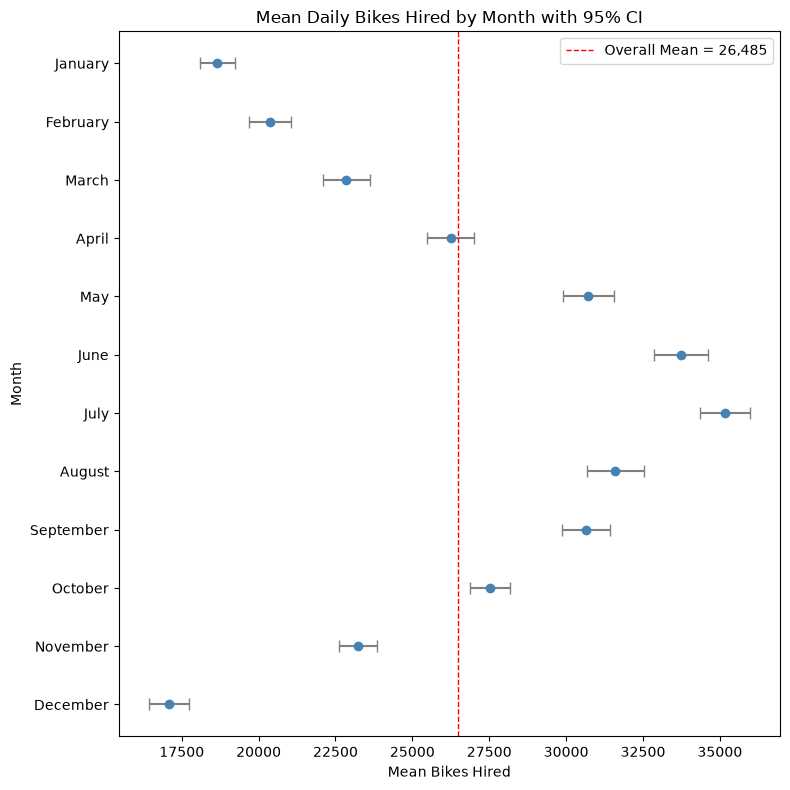

In [13]:
# Sort so January appears at the top of the plot
plot_df = month_ci.sort_values('month_name', ascending=False)

plt.figure(figsize=(8, 8))

# Plot the mean rentals as points with horizontal error bars
plt.errorbar(
    x=plot_df['mean_rentals'],            # mean bikes hired
    y=plot_df['month_name'],              # month labels
    xerr=plot_df['margin_of_error'],      # half-length of CI
    fmt='o',                              # point marker
    color='steelblue',                    # point color
    ecolor='gray',                        # error bar color
    capsize=4,                            # cap size on error bars
    markersize=6                          # marker size
)

# Add a vertical line for overall mean rentals
overall_mean = plot_df['mean_rentals'].mean()
plt.axvline(
    overall_mean,
    color='red', linestyle='--', linewidth=1,
    label=f'Overall Mean = {overall_mean:,.0f}'
)

# Labels and title
plt.xlabel('Mean Bikes Hired')
plt.ylabel('Month')
plt.title('Mean Daily Bikes Hired by Month with 95% CI')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

*Your write-up goes here — based on `season_ci` / `month_ci` and the plots above, address:*
- **What range of values do you expect the true mean to lie in?**
    - Spring and Autumn's confidence intervals sit between Summer and Winter, as expected. We are 95% confident the true mean number of bikes hired daily falls between roughly 26,100 and 27,100 in Spring, and between roughly 26,700 and 27,600 in Autumn.

- **Which seasons/months have higher or lower average demand?**
    - The seasons and months that have a lower demand are the winter months of December, January, and February. The seasons that have a higher average demand are the summer months of June, July, and August. 

- **Are there overlaps in the intervals, and what does that mean?**
    - Yes, there are overlaps in the spring and autumn seasons/months roughly have the same averages as eachother. This suggests that their number of average bikes rented are not statistically significantly different from eachother. 

**Regression Analysis**

What variables influence the number of bikes rented (y) and how? Build a regression model that best explains the variability in bikes rented.

**Interpret:**

Which predictors are significant?

What do the coefficients mean (in practical terms)?

How much of the variation in bike rentals is explained (R²)?

**Deliverables:**

Regression output table.

A short discussion of which factors matter most for predicting bike rentals.

In [18]:
### Your code goes here
model0_multiple = smf.ols('bikes_hired ~ month', data=bikes).fit()
print(model0_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:            bikes_hired   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     250.7
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:56:22   Log-Likelihood:                -51185.
No. Observations:                4934   AIC:                         1.024e+05
Df Residuals:                    4922   BIC:                         1.025e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     2.624e+04    392.767     66.813   

## Deliverables
A knitted HTML, one person per group to submit